# 02 — Baseline : le modèle avant fine-tuning

**Objectif :** mesurer la performance du modèle de base, **sans aucun entraînement**, sur le jeu de test. C'est le point de référence : le fine-tuning LoRA (notebook 03) ne sera utile que s'il fait nettement mieux.

**Modèle choisi : `Qwen2.5-Coder-1.5B-Instruct`**
- 1,5 milliard de paramètres : assez petit pour un GPU T4 gratuit, et réaliste pour un déploiement interne
- spécialisé en code, donc il connaît déjà la syntaxe SQL
- licence Apache 2.0 : utilisable en entreprise

**Métriques :**

| Métrique | Signification |
|---|---|
| **Execution accuracy** (principale) | La requête générée renvoie le même résultat que la requête de référence |
| Taux de SQL valide | La requête s'exécute sans erreur (même si le résultat est faux) |
| Exact match | Le texte SQL est identique à la référence (métrique stricte, donnée à titre indicatif) |


## 0. Installation

In [3]:
import os, sys

REPO_URL = "https://github.com/eya-bouhmida/finance-text2sql-lora"
REPO_DIR = "/content/text2sql-finance-qlora"

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
    else:
        !cd {REPO_DIR} && git pull
    %cd {REPO_DIR}
    !pip install -q transformers accelerate peft datasets
    sys.path.append(REPO_DIR)
    from google.colab import drive
    drive.mount("/content/drive")
else:
    sys.path.append("..")

DATA_DIR = "/content/drive/MyDrive/text2sql-finance-qlora/data" if IN_COLAB else "../data"
RESULTS_DIR = f"{REPO_DIR}/results" if IN_COLAB else "../results"

Already up to date.
/content/text2sql-finance-qlora
Mounted at /content/drive


In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from src import data as D, model as M, evaluate as E

pd.set_option("display.max_colwidth", 150)
print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "AUCUN (active le GPU T4)")

GPU : Tesla T4


## 1. Chargement du jeu de test

On utilise le fichier `test.jsonl` créé dans le notebook 01. Les **mêmes questions** seront utilisées pour évaluer le modèle fine-tuné dans le notebook 04, ce qui garantit une comparaison équitable.

In [5]:
test_records = D.load_jsonl(f"{DATA_DIR}/test.jsonl")

# Pour aller plus vite pendant les essais, on peut limiter le nombre de questions.
# Mettre None pour évaluer tout le jeu de test (à faire pour les résultats finaux).
N_EVAL = None
if N_EVAL:
    import random
    random.Random(42).shuffle(test_records)
    test_records = test_records[:N_EVAL]

print(f"Questions évaluées : {len(test_records)}")
pd.Series([r["sql_complexity"] for r in test_records]).value_counts()

Questions évaluées : 158


,count
basic SQL,79
single join,35
aggregation,31
window functions,6
subqueries,5
multiple_joins,2


## 2. Chargement du modèle de base

In [6]:
model, tokenizer = M.load_model(M.BASE_MODEL)

n_params = sum(p.numel() for p in model.parameters())
print(f"Modèle : {M.BASE_MODEL}")
print(f"Paramètres : {n_params / 1e9:.2f} milliards")
print(f"Mémoire GPU utilisée : {torch.cuda.memory_allocated() / 1e9:.1f} Go")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modèle : Qwen/Qwen2.5-Coder-1.5B-Instruct
Paramètres : 1.54 milliards
Mémoire GPU utilisée : 3.1 Go


### 2.1 Un premier essai

In [7]:
ex = test_records[0]
for m in ex["messages"]:
    print(f"[{m['role'].upper()}]\n{m['content']}\n")

raw, _ = M.generate(model, tokenizer, [ex["messages"]])
print("=== Réponse brute du modèle ===\n", raw[0])
print("\n=== SQL extrait ===\n", E.extract_sql(raw[0]))
print("\n=== Requête de référence ===\n", ex["gold_sql"])
print("\n=== Évaluation ===\n", E.evaluate_one(ex["context"], ex["gold_sql"], E.extract_sql(raw[0])))

[SYSTEM]
You are an expert SQL assistant for financial databases. Given a database schema and a question, write a single SQLite query that answers it. Return only the SQL query.

[USER]
### Schema:
CREATE TABLE daily_investments (client_id INT, date DATE, investment FLOAT);

### Question:
What is the maximum daily investment for each client?

1/1
=== Réponse brute du modèle ===
 ```sql
SELECT client_id, MAX(investment) AS max_daily_investment
FROM daily_investments
GROUP BY client_id;
```

=== SQL extrait ===
 SELECT client_id, MAX(investment) AS max_daily_investment
FROM daily_investments
GROUP BY client_id;

=== Requête de référence ===
 SELECT client_id, MAX(investment) OVER (PARTITION BY client_id ORDER BY client_id) as max_daily_investment FROM daily_investments;

=== Évaluation ===
 {'executable': True, 'execution_match': True, 'exact_match': False, 'pred_error': None}


## 3. Génération sur tout le jeu de test

Décodage **glouton** (`do_sample=False`) : le modèle choisit toujours le token le plus probable, ce qui rend les résultats **reproductibles**.

In [8]:
raw_outputs, sec_per_question = M.generate(
    model, tokenizer, [r["messages"] for r in test_records], batch_size=8
)
print(f"Temps moyen par question : {sec_per_question:.2f} s")

158/158
Temps moyen par question : 0.39 s


## 4. Résultats de la baseline

In [9]:
results = E.evaluate_predictions(test_records, raw_outputs)
summary = E.summarize(results)
summary["sec_per_question"] = round(sec_per_question, 3)
summary["model"] = M.BASE_MODEL

pd.Series(summary)

,0
n,158
execution_accuracy,58.86
valid_sql_rate,92.41
exact_match,24.68
sec_per_question,0.386
model,Qwen/Qwen2.5-Coder-1.5B-Instruct


In [10]:
by_complexity = E.summarize_by(results, "sql_complexity")
by_complexity

,n,execution_accuracy,valid_sql_rate
sql_complexity,,,
basic SQL,79,67.1,97.5
single join,35,54.3,82.9
aggregation,31,54.8,100.0
window functions,6,33.3,83.3
subqueries,5,40.0,60.0
multiple_joins,2,0.0,50.0


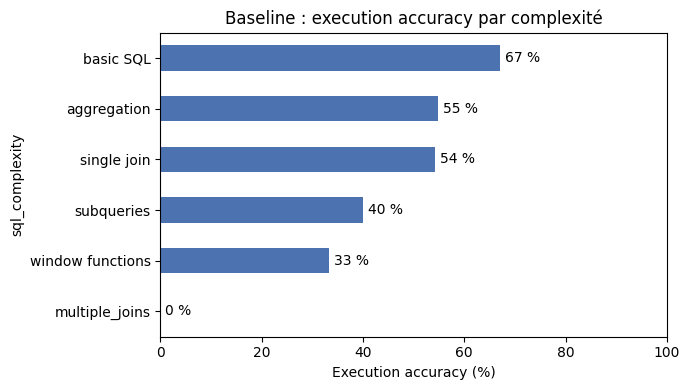

In [11]:
ax = by_complexity["execution_accuracy"].sort_values().plot.barh(figsize=(7, 4), color="#4C72B0")
ax.set_xlabel("Execution accuracy (%)")
ax.set_xlim(0, 100)
ax.set_title("Baseline : execution accuracy par complexité")
for i, v in enumerate(by_complexity["execution_accuracy"].sort_values()):
    ax.text(v + 1, i, f"{v:.0f} %", va="center")
plt.tight_layout(); plt.show()

## 5. Analyse des erreurs

On distingue deux types d'échecs :
- **SQL invalide** : la requête ne s'exécute pas (erreur de syntaxe, colonne inventée, fonction non SQLite…)
- **SQL valide mais faux** : la requête s'exécute mais ne renvoie pas le bon résultat (mauvaise jointure, mauvais filtre…)

In [12]:
failures = results[~results["execution_match"]]
error_types = pd.Series({
    "SQL invalide": int((~failures["executable"]).sum()),
    "SQL valide mais résultat faux": int(failures["executable"].sum()),
})
print(error_types)

print("\nErreurs d'exécution les plus fréquentes :")
failures["pred_error"].dropna().str.split(":").str[0:2].str.join(":").value_counts().head(8)

SQL invalide                     12
SQL valide mais résultat faux    53
dtype: int64

Erreurs d'exécution les plus fréquentes :


,count
pred_error,
OperationalError: no such column,9
OperationalError: no such function,2
OperationalError: no such table,1


In [13]:
# Quelques exemples d'échecs, à commenter dans l'analyse
failures[["sql_complexity", "question", "gold_sql", "pred_sql", "pred_error"]].head(5)

,sql_complexity,question,gold_sql,pred_sql,pred_error
2,basic SQL,What are the names and total transactions of all Shariah-compliant financial institutions from the finance database?,"SELECT name, SUM(total_transactions) FROM shariah_compliant_institutions;","SELECT name, total_transactions FROM shariah_compliant_institutions;",None
6,basic SQL,List all Shariah-compliant financial products offered in the Southeast Asian region,SELECT product_name FROM shariah_compliant_products WHERE region = 'Southeast Asia';,SELECT product_name FROM shariah_compliant_products WHERE region = 'Southeast Asian';,None
10,basic SQL,What is the average account balance for clients in Asia in Q2 2022?,"SELECT AVG(balance) as avg_balance FROM accounts WHERE country IN ('India', 'China', 'Japan') AND account_date BETWEEN '2022-04-01' AND '2022-06-30';","SELECT AVG(balance) AS avg_balance\nFROM accounts\nWHERE country = 'Asia'\nAND strftime('%Y-%m', account_date) LIKE '2022-04-%';",None
13,single join,Display policy_id and sum_insured for policies where the sum insured is less than 60000 and policyholder gender is female,"SELECT policy_info.policy_id, policy_info.sum_insured FROM policy_info INNER JOIN policyholder ON policy_info.policy_id = policyholder.policy_id W...","SELECT policy_id, sum_insured FROM policy_info WHERE sum_insured < 60000 AND policyholder.gender = 'Female';",OperationalError: no such column: policyholder.gender
15,aggregation,How many clients have taken out socially responsible loans in each country?,"SELECT country, COUNT(DISTINCT client_id) as num_clients FROM socially_responsible_loans GROUP BY country;","SELECT COUNT(*) AS num_clients, country FROM socially_responsible_loans GROUP BY country;",None


## 6. Sauvegarde

In [14]:
os.makedirs(RESULTS_DIR, exist_ok=True)
results.to_csv(f"{RESULTS_DIR}/02_baseline_predictions.csv", index=False)
by_complexity.to_csv(f"{RESULTS_DIR}/02_baseline_by_complexity.csv")
E.save_json(summary, f"{RESULTS_DIR}/02_baseline_metrics.json")
print("Résultats sauvegardés dans", RESULTS_DIR)

Résultats sauvegardés dans /content/text2sql-finance-qlora/results


## Conclusion de la baseline

Le modèle de base Qwen2.5-Coder-1.5B atteint 58,9 % d’execution accuracy sur 158 questions financières. Il maîtrise la syntaxe SQL (92,4 % de requêtes valides), mais un tiers de ses réponses sont des requêtes valides qui renvoient un mauvais résultat : son point faible est la compréhension de la question et du schéma, plutôt que la syntaxe. Les performances baissent sur les jointures (54 %) et les agrégations (55 %). L’objectif du fine-tuning LoRA est de corriger ces erreurs de logique.

**Prochaine étape :** notebook 03, fine-tuning avec LoRA pour corriger ces faiblesses.